<h1 style = "color : #0EE071; text-align : center;"><em>Nata Project</em> - NB1: Data Exploration Notebook</h1>
<p style = "font-size : 16px; text-align: center;">This notebook is dedicated only to the exploration of the <code>Nata_Files/learn.csv</code> dataset</p>
<br>
<p style = "font-size : 12px; text-align: center;"><b>NOVA IMS</b></p>
<p style = "font-size : 10px; text-align: center;">Machine Learning I</p>
<p style = "font-size : 10px; text-align: center;">Diogo Gonçalves, João Marques, Juan Mendes, Gustavo Franco & Lucas Casimiro</p>
<br>


<h2  style = "color : #0EE071;">1. Imports</h2>

In [149]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">2. Dataset Loading </h2>

<p style = "font-size : 15px;">Reading of dataset from <code>learn.csv</code> file</p>
<p>The dataset is in a <code>.csv</code> file. We are also adopting the column <code>id</code> as index, thus <code>index_col = 0</code>. </p>

In [150]:
learn_data = pd.read_csv("Nata_Files/learn.csv", index_col = 0)

<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">3. Dataset Interpretation </h2>
<p style = "font-size : 20px;">What is <code>learn.csv</code> file about?</p>

<p>As we know from the guidelines, this dataset <code>learn.csv</code> is the collection of information (on recipe, baking, etc) of several bakeries of Pastel de Nata in Porto and Lisbon.</p>
<p>For each entry (recipe and baking conditions), there is a target variable: weather the Pastel de Nata got ou <code>OK</code> (approved by Nata Visionaries) or <code>KO</code> (rejected).</p>
<p>This data was collected from different bakeries, so we don't have a homogenous source. This means we have to be careful analysing the details, ensuring maximum homogenety.</p>
<p><b>Our objective:</b> Make efforts in order to build a Classification Model that accuratly predicts the qualitu of a Pastel de Nata solely based on its production parameters.</p>
<p>Success for this project will be measured specifically by the Accuracy of our predictions on unseen data, as we strive to replicate the rigorous standards of the Nata Visionaries brotherhood.</p>
<br>

<p>To have an idea of what are the features we have, we can load the <code>data_dictionary.csv</code> dataset, to briefly see what are these features, what is their type, their description and unit.</p>
<p>Going forward on this project, will be vital to know, in practice, what we are dealing with.</p>

In [151]:
data_dictionary = pd.read_csv("Nata_Files/data_dictionary.csv", index_col = 0)
data_dictionary

,Type,Description,Unit
Feature,,,
id,Numeric,Internal identifier for each record,-
ambient_humidity,Numeric,Kitchen ambient humidity during baking,%
baking_duration,Numeric,Total baking time at high temperature,minutes
cooling_period,Numeric,Resting time after baking before removal,minutes
cream_fat_content,Numeric,Fat percentage in cream used,%
egg_temperature,Numeric,Temperature of eggs when added to custard,°C
egg_yolk_count,Numeric,Number of egg yolks per batch,count
final_temperature,Numeric,Measured temperature at end of baking,°C
lemon_zest_ph,Numeric,pH of lemon zest infusion in custard,pH scale


<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">4. Dataset Overview </h2>
<p style = "font-size : 20px;">How is <code>learn.csv</code> structured?</p>

<h3 style = "color : #0EE071;">4.1. Basic Structure </h3>

<p>Firstly, we call the method <code>.head()</code> to see the first 5 rows of this dataset.</p>
<p>

In [152]:
learn_data.head()

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,origin,oven_temperature,pastry_type,preheating_time,salt_ratio,sugar_content,vanilla_extract,quality_class
id,,,,,,,,,,,,,,,,,
1,54.0,24.0,26.0,100.4,52.0,11.0,309.0,3.2,NaN,Lisboa,NaN,Pastel Nata,207.0,42.74,22.8,5.7,KO
2,66.0,37.0,34.0,98.0,46.0,10.0,317.0,3.3,NaN,Lisboa,306.0,NaN,245.0,41.73,11.6,4.0,KO
3,41.0,30.0,19.0,99.3,53.0,10.0,130.0,3.4,NaN,Porto,121.0,NaN,186.0,75.10,20.3,7.5,OK
4,62.0,24.0,48.0,98.0,115.0,9.0,354.0,3.3,NaN,Lisboa,357.0,Pastel de Nata,186.0,46.41,73.3,4.2,OK
5,55.0,21.0,34.0,100.1,48.0,9.0,211.0,3.0,NaN,Lisboa,202.0,Pastel de nata,218.0,56.52,80.1,6.0,KO


<p>Then let's proceed to see the <code>.info()</code> method of this dataset. Here it will be possible to have an idea of which rows have more missing values and their Pandas dtypes. </p>

In [153]:
learn_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5200 entries, 1 to 5200
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ambient_humidity   5182 non-null   float64
 1   baking_duration    5199 non-null   float64
 2   cooling_period     5199 non-null   float64
 3   cream_fat_content  5176 non-null   float64
 4   egg_temperature    5176 non-null   float64
 5   egg_yolk_count     5176 non-null   float64
 6   final_temperature  5175 non-null   float64
 7   lemon_zest_ph      5174 non-null   float64
 8   notes_baker        0 non-null      float64
 9   origin             5039 non-null   object 
 10  oven_temperature   5179 non-null   float64
 11  pastry_type        3411 non-null   object 
 12  preheating_time    5181 non-null   float64
 13  salt_ratio         5187 non-null   float64
 14  sugar_content      5178 non-null   float64
 15  vanilla_extract    5182 non-null   float64
 16  quality_class      5199 non-n

<p>Another well-known method to see how many columns and rows are we talking about here is <code>.shape</code>.</p>

In [154]:
learn_data.shape

(5200, 17)

<p>Lastly, on the methods to see some superficial information on our dataset, we are callinf <code>.describe()</code>, which will go through the numerical columns and calculate some useful measures.</p>

In [155]:
learn_data.describe()

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,notes_baker,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract
count,5182.000000,5199.000000,5199.000000,5176.00000,5176.000000,5176.000000,5175.000000,5174.000000,0.0,5179.000000,5181.000000,5187.000000,5178.000000,5182.000000
mean,59.980316,26.979804,31.817850,98.41306,70.812403,10.498068,223.577198,3.218902,NaN,223.541031,216.413241,55.882034,54.003418,5.307159
std,11.616151,8.320079,14.427143,1.99735,35.439831,1.257709,85.258779,0.165909,NaN,84.482034,39.533116,34.867144,47.213038,1.483175
min,40.000000,14.000000,0.000000,91.90000,12.000000,8.000000,31.000000,2.700000,NaN,58.000000,114.000000,11.550000,6.000000,2.200000
25%,50.000000,21.000000,25.000000,97.10000,44.000000,10.000000,164.000000,3.100000,NaN,166.000000,192.000000,37.910000,18.000000,4.300000
50%,60.000000,25.000000,31.000000,98.40000,67.000000,10.000000,226.000000,3.200000,NaN,227.000000,209.000000,47.170000,30.000000,5.100000
75%,70.000000,30.000000,39.000000,99.80000,92.000000,11.000000,284.000000,3.300000,NaN,283.000000,231.000000,64.610000,80.675000,6.000000
max,80.000000,89.000000,105.000000,107.30000,575.000000,15.000000,722.000000,4.000000,NaN,713.000000,499.000000,640.320000,656.500000,20.800000


<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
<p>This dataset has <b>17 columns</b> and <b>5200 rows.</b>
<p>We are dealing with 2 categorical features (<code>origin</code> and <code>pastry_type</code>), 1 text feature and 13 numerical features. We also have our target variable, <code>quality_class</code>, which is categorical.</p>
</div>
<br>
<br>

<h3 style = "color : #0EE071;">4.2. Missing Values </h3>

In [156]:
learn_data.isnull().sum()/5200*100

ambient_humidity       0.346154
baking_duration        0.019231
cooling_period         0.019231
cream_fat_content      0.461538
egg_temperature        0.461538
egg_yolk_count         0.461538
final_temperature      0.480769
lemon_zest_ph          0.500000
notes_baker          100.000000
origin                 3.096154
oven_temperature       0.403846
pastry_type           34.403846
preheating_time        0.365385
salt_ratio             0.250000
sugar_content          0.423077
vanilla_extract        0.346154
quality_class          0.019231
dtype: float64

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
<ul>
    <li><code>ambient_humidity</code>: Numerical - 0.34% missing values</li>
    <li><code>baking_duration</code>: Numerical - 0.02% missing values</li>
    <li><code>cooling_period</code>: Numerical - 0.2% missing values</li>
    <li><code>cream_fat_content</code>: Numerical - 0.46% missing values</li>
    <li><code>egg_temperature</code>: Numerical - 0.46% missing values</li>
    <li><code>egg_yolk_count</code>: Numerical - 0.46% missing values</li>
    <li><code>final_temperature</code>: Numerical - 0.48% missing values</li>
    <li><code>lemon_zest_ph</code>: Numerical - 0.5% missing values</li>
    <li><code>notes_baker</code>: <b>All Values Missings</b> - 100% missing values</li>
    <li><code>origin</code>: Categorical - 3.1% missing values</li>
    <li><code>oven_temperature</code>: Numerical - 0.40% missing values</li>
    <li><code>pastry_type</code>: Categorical - 34.40% missing values</li>
    <li><code>preheating_time</code>: Numerical - 0.36% missing values</li>
    <li><code>salt_ratio</code>: Numerical - 0.25% missing values</li>
    <li><code>sugar_content</code>: Numerical - 0.42% missing values</li>
    <li><code>vanilla_extract</code>: Numerical - 0.34% missing values</li>
    <li><code>quality_class</code>: Categorical - 0.02% missing values</li>
</ul>
</div>
<br>

<h3 style = "color : #0EE071;">4.3. Duplicate Check</h3>

<p>We should also, very quickly, check for any duplicates this dataset might have.</p>

In [157]:
print(f'Duplicates: {learn_data.duplicated().sum()}')

Duplicates: 2


<p>As we found 2 duplicates, 

<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">5. Feature Exploration </h2>
<p style = "font-size : 20px;">What are the <code>learn.csv</code> features?</p>

<h3 style = "color : #0EE071;">5.1 Categorical Features Analysis</h3>

<p>The categorical features, that we are going to analyse here are: <code>origin</code>, <code>pastry_type</code> and <code>quality_class</code>.

In [158]:
categorical_cols = ['origin', 'pastry_type', 'quality_class'] # creating a list of all the categorical columns


<p>Starting off by checking the unique values of each row:</p>

In [159]:
for col in categorical_cols:
    unique_values = learn_data[col].unique()  # collect unique values
    print(f"COLUMN: {col}\nUNIQUE VALUES: {unique_values}\n\n") # print them

COLUMN: origin
UNIQUE VALUES: ['Lisboa' 'Porto' ' Lisboa' 'Porto ' 'LISBOA' 'PORTO' 'lisboa' nan
 'Lisboa ' 'porto' ' Porto']


COLUMN: pastry_type
UNIQUE VALUES: ['Pastel Nata' nan 'Pastel de Nata' 'Pastel de nata' 'Pastel De Nata']


COLUMN: quality_class
UNIQUE VALUES: ['KO' 'OK' nan]




<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
<p>From here we can tell that:</p>
<ul>
    <li><code>origin</code>: Has only 2 real categories (Lisbon and Porto) and missing values.</li>
    <li><code>pastry_type</code>: Has only 1 real category (Pastel de Nata) and missing values.</li>
    <li><code>quality_class</code>: Has indeed 2 categories (OK and KO) and missing values.</li>
</ul>

<p>From here, we can take what are the varients/erros of each category.</p>
</div>

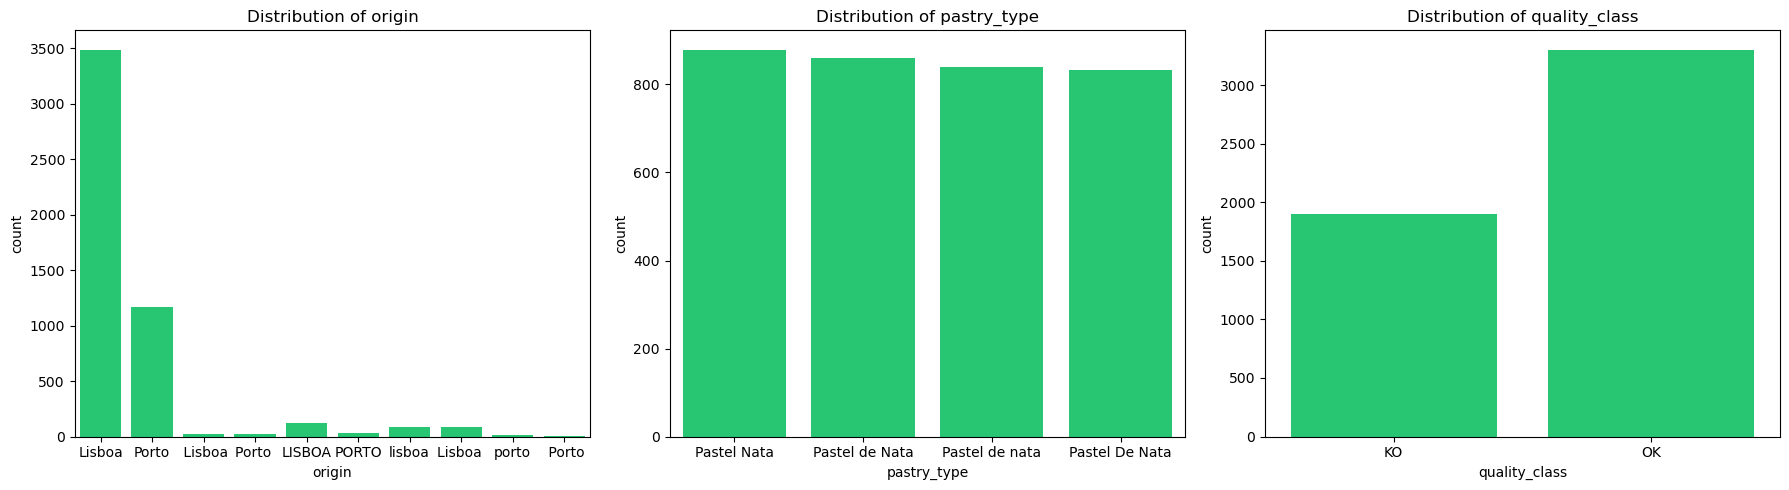

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # creating the figure with 3 subplots
for ax, col in zip(axes, categorical_cols): # iteration over categorical columns, assigning them to subplots/axes
    sns.countplot(data=learn_data, x=col, ax=ax, color='#0EE071') # creating countplot for each categorical column
    ax.set_title(f'Distribution of {col}') # setting title for each subplot
plt.tight_layout() # adjusting layout
plt.show() # displaying the plots

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">

<ul>
    <li><code>origin</code>: The most popular spelling of each category is <code>Lisboa</code> and <code>Porto</code>, so we should standardise those.</li>
    <li><code>pastry_type</code>: There is only one real category, so apart from possible standardisation of the category, there is no big point on this feature.</li>
    <li><code>quality_class</code>: We can here tell that there is a big <code>OK</code> categorised Pastel de Nata than <code>KO</code>.</li>
</ul>

</div>

<h3 style = "color : #0EE071;">5.2. Numerical Features Analysis</h3>

<p>Let's collect the numerical features names into one list:</p>

In [161]:
numerical_cols = learn_data.select_dtypes(include=np.number).columns.tolist() # creating a list of all the numerical columns 

<p>Starting off by seeing the boxplots, excluding missing values, of the features:</p>

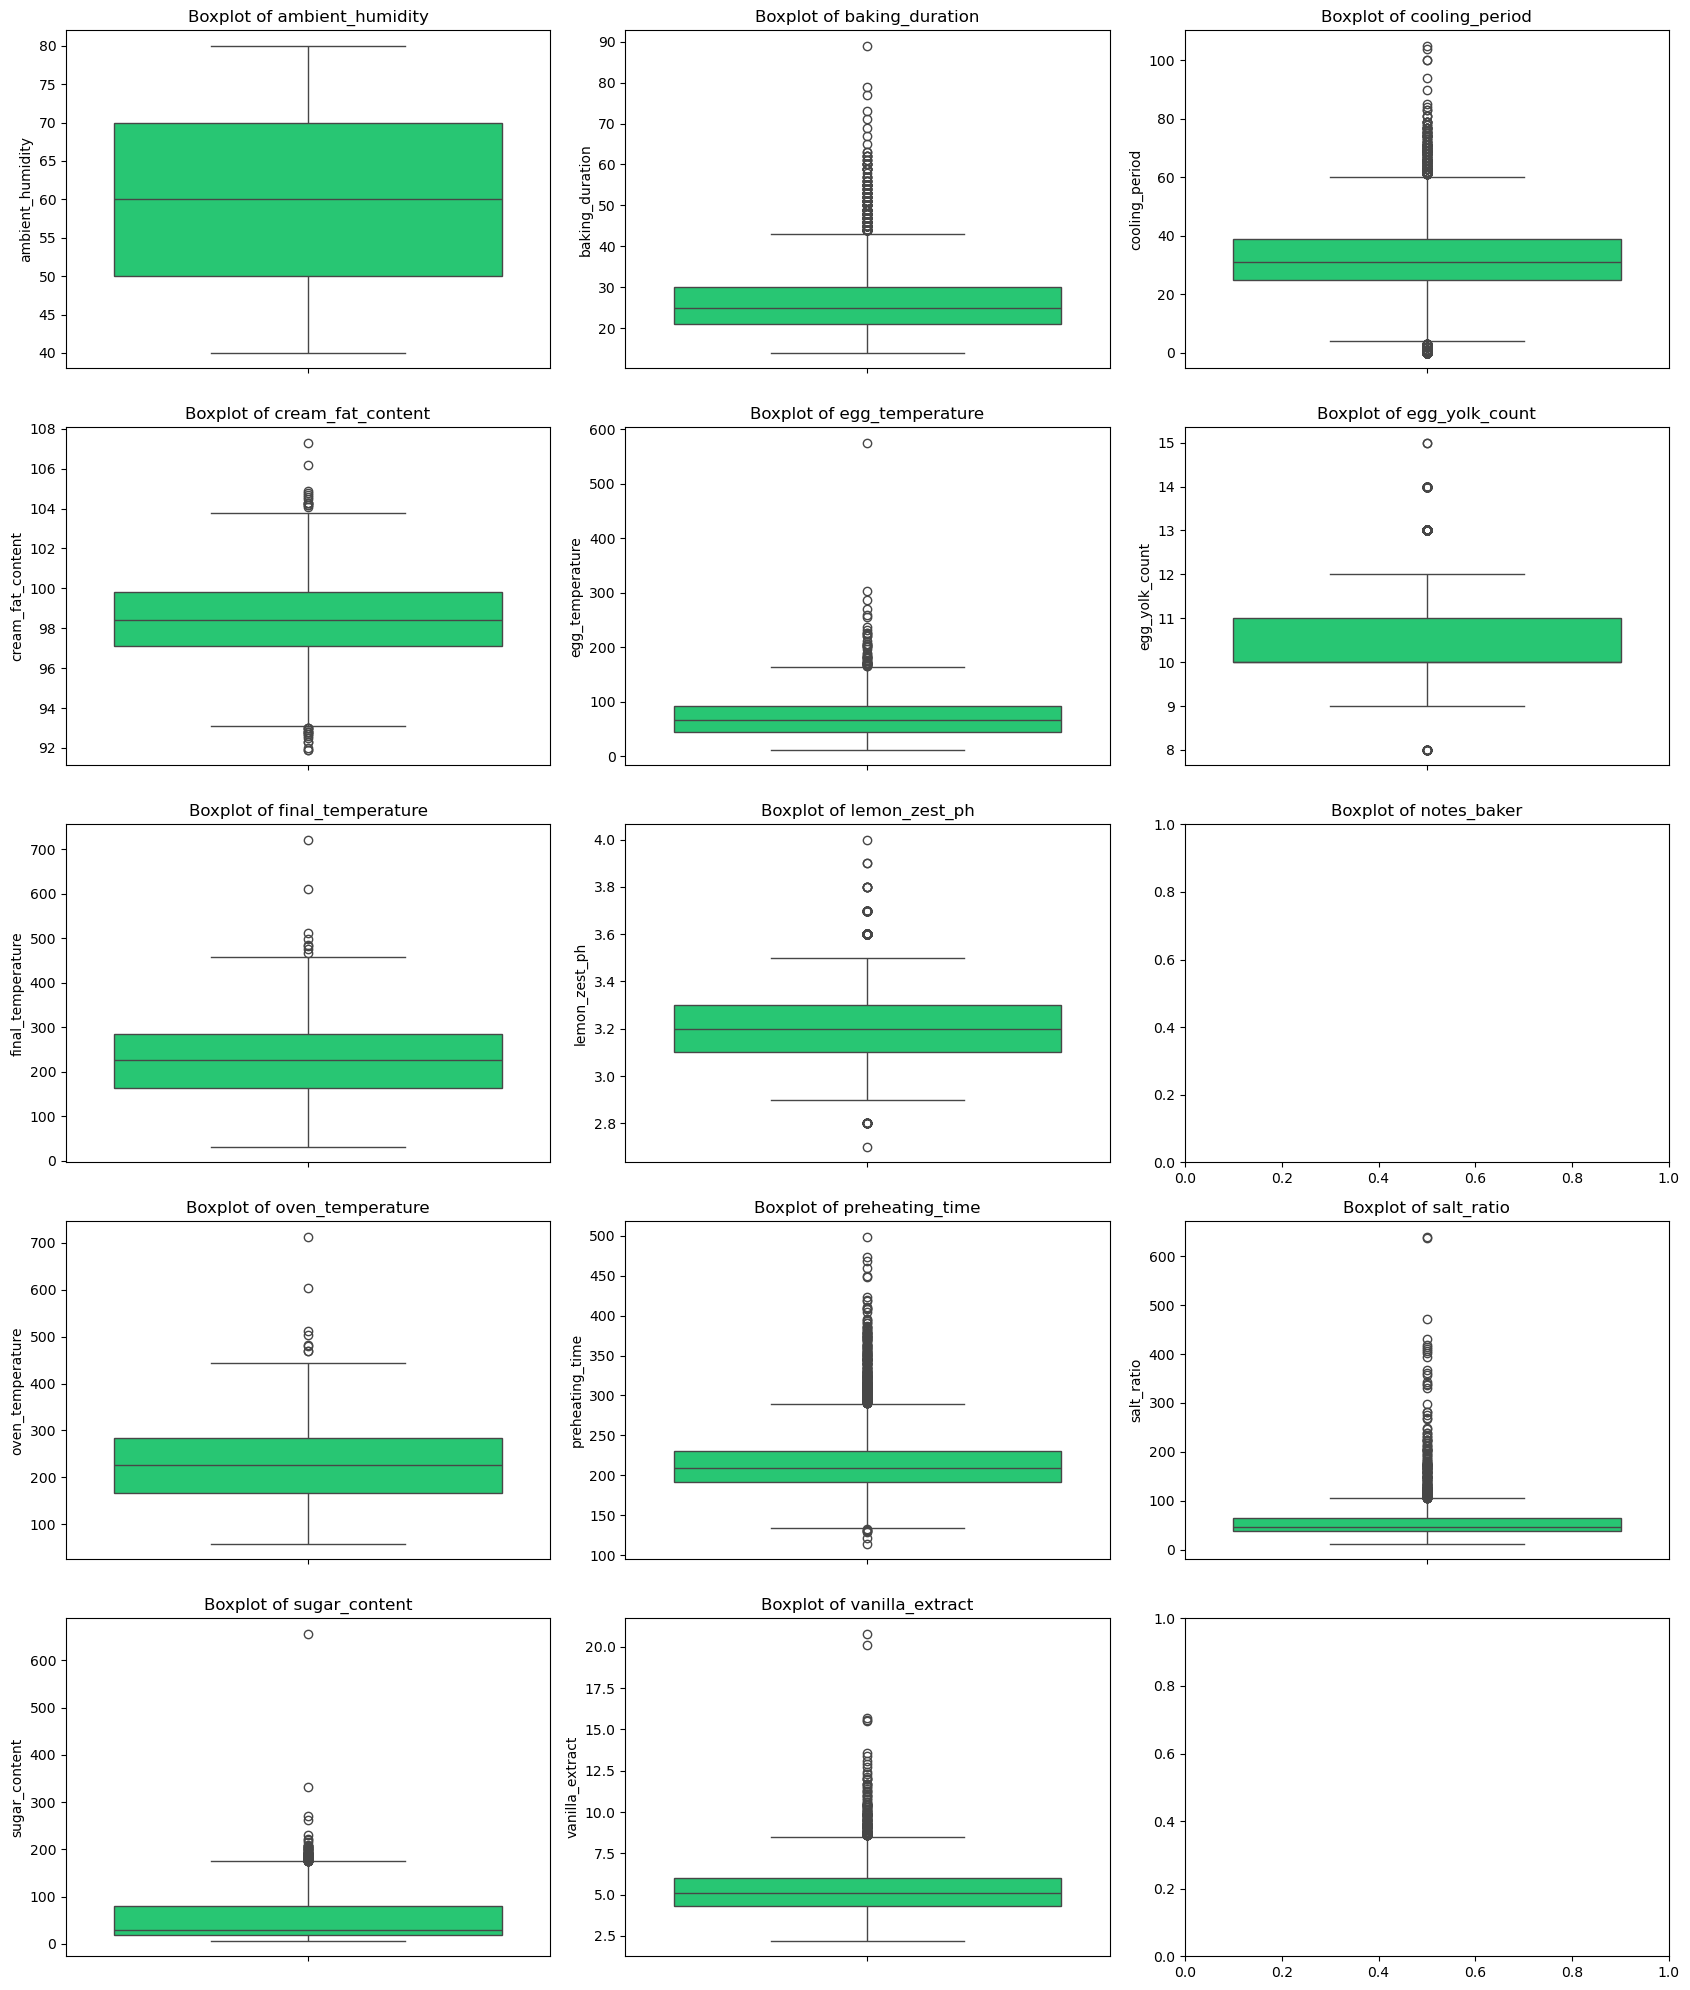

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(17, 4 * 5)) # Setting the subplots grid
axes = axes.flatten()

# Plot a boxplot for each numerical feature
for i, col in enumerate(numerical_cols):
    sns.boxplot(learn_data[col].dropna(), ax=axes[i], color='#0EE071')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)

plt.tight_layout()
plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
<p>By analysing this boxplots, we can see that:</p>
<ul>
<li>The <code>egg_temperature</code>, <code>final_temperature</code> and <code>oven_temperature</code> have completly unrealistic outliers (for example, temperatures above 500ºC), those are probably <b>data errors</b>.</li>
<li>The <code>salt_ratio</code> and <code>sugar_content</code> also have unrealistic outliers.</li>

</div>

<p>Now, proceesing to the distributions of the features:</p>

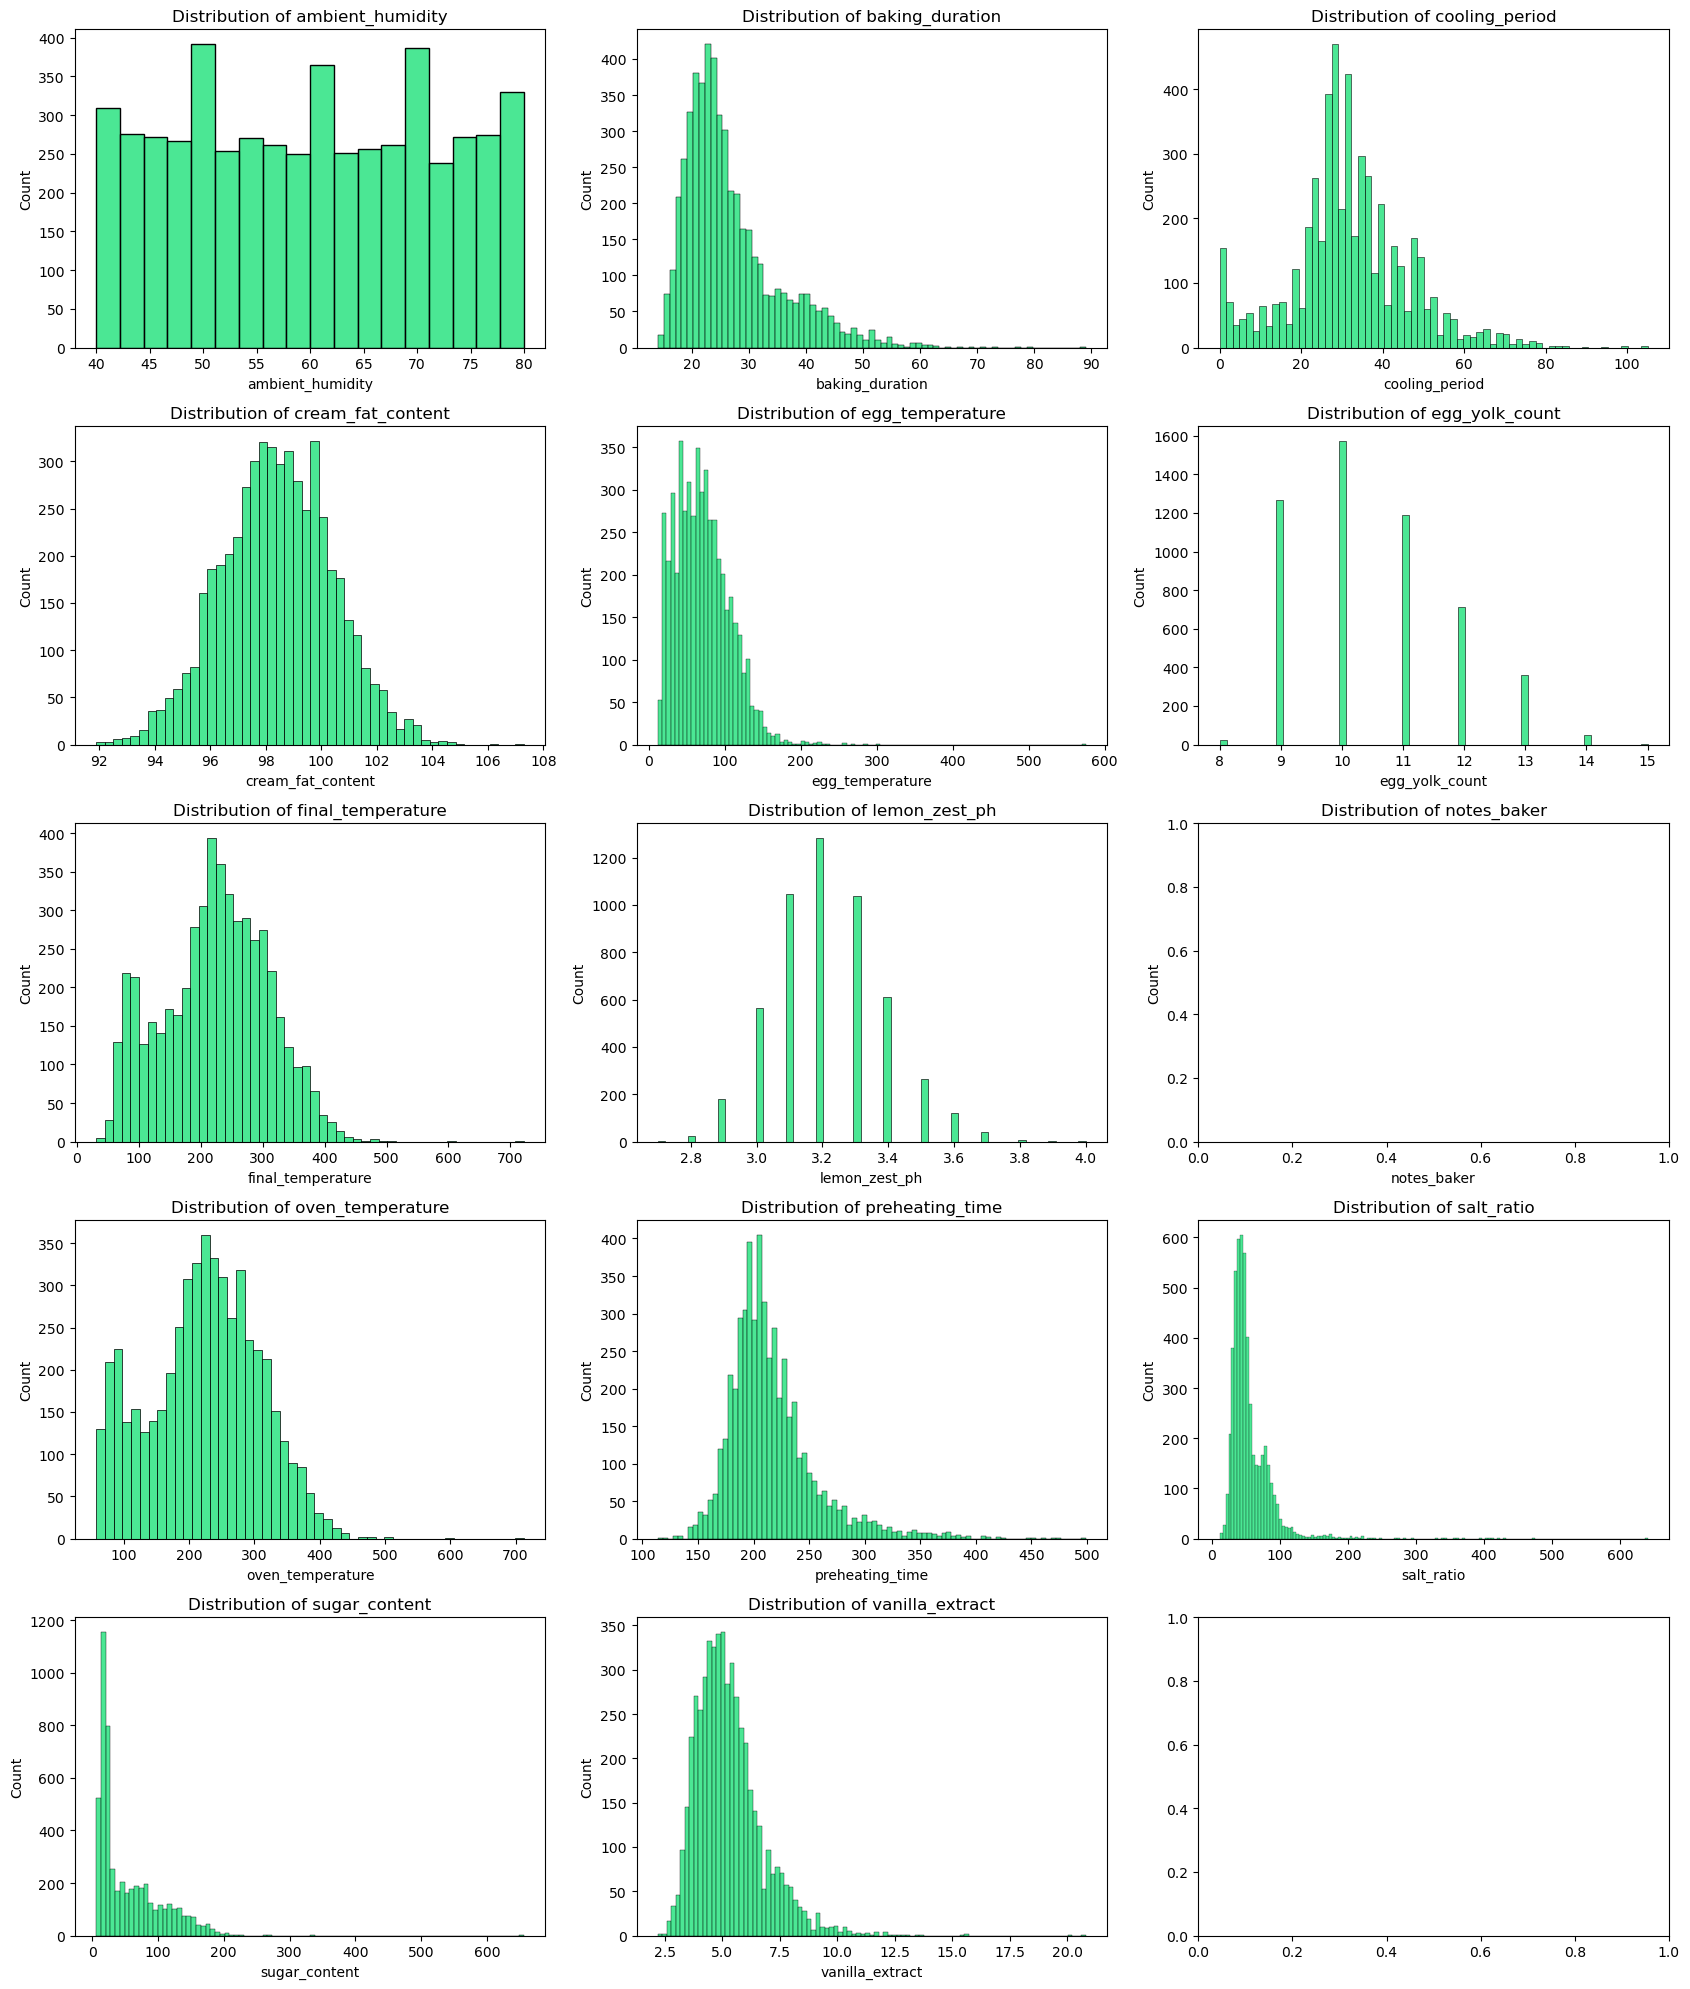

In [163]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(17, 4 * 5)) # Setting the subplots grid
axes = axes.flatten()

# Plot a histogram for each numerical feature
for i, col in enumerate(numerical_cols):
    sns.histplot(learn_data[col].dropna(), ax=axes[i], color='#0EE071')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;">
<p>Right-skewed features:</p>
<ul>
    <li><code>baking_duration</code></li>
    <li><code>cooling_period</code></li>
    <li><code>egg_temperature</code> - <b>Severely Right-Skewed</b></li>
    <li><code>oven_temperature</code> - <b>Severely Right-Skewed</b></li>
    <li><code>preheating_time</code></li>
    <li><code>salt_ratio</code> - <b>Severely Right-Skewed</b></li>
    <li><code>sugar_content</code> - <b>Severely Right-Skewed</b></li>
    <li><code>vanilla_extract</code> - <b>Severely Right-Skewed</b></li>
</ul>
<p>Symmetric/Normal distributed features:</p>
<ul>
    <li><code>ambient_humidity</code></li>
    <li><code>cream_fat_content</code></li>
    <li><code>lemon_zest_ph</code> - <b>Severely Right-Skewed</b></li>
</ul>
<p>Discrete feature:</p>
<ul><li><code>egg_yolk_count</code></li></ul>
<br>
<p>The <b>Symmetric distributed</b> features, won't require heavy transformations. While some of the <b>Right-skewed</b> features might require some kind of transformation ranging from outliers treatment to logarithmic scaling. Regarding <code>egg_yolk_count</code>, we know that it is numerical, but it varies from 8 to 15 and might behave like a categorical feature.</p>

<p>Additionally, we should note that:</p>
<ul>
    <li><code>notes baker</code> is supposed to be a <code>text</code> feature, but its Pandas dtype is a <code>float64</code> - we don't have any values for it, so it should be dropped.</li>
</ul>
</div>

<h3 style = "color : #0EE071;">5.2. Bivariate Analysis</h3>

<p>We should then compare the numerical features with the target variable.</p>
<p>In this analysis, we excluded the categorical features, as they are not yet prepared for this kind of analysis, and the <code>notes_baker</code> as it would be irrelevant.</p>
<p>Here we are laying some foundations to later analyse more powerful features that directly affect the outcome</p>

In [164]:
palette = {'OK': '#0EE071', 'KO': "#0933ED"}

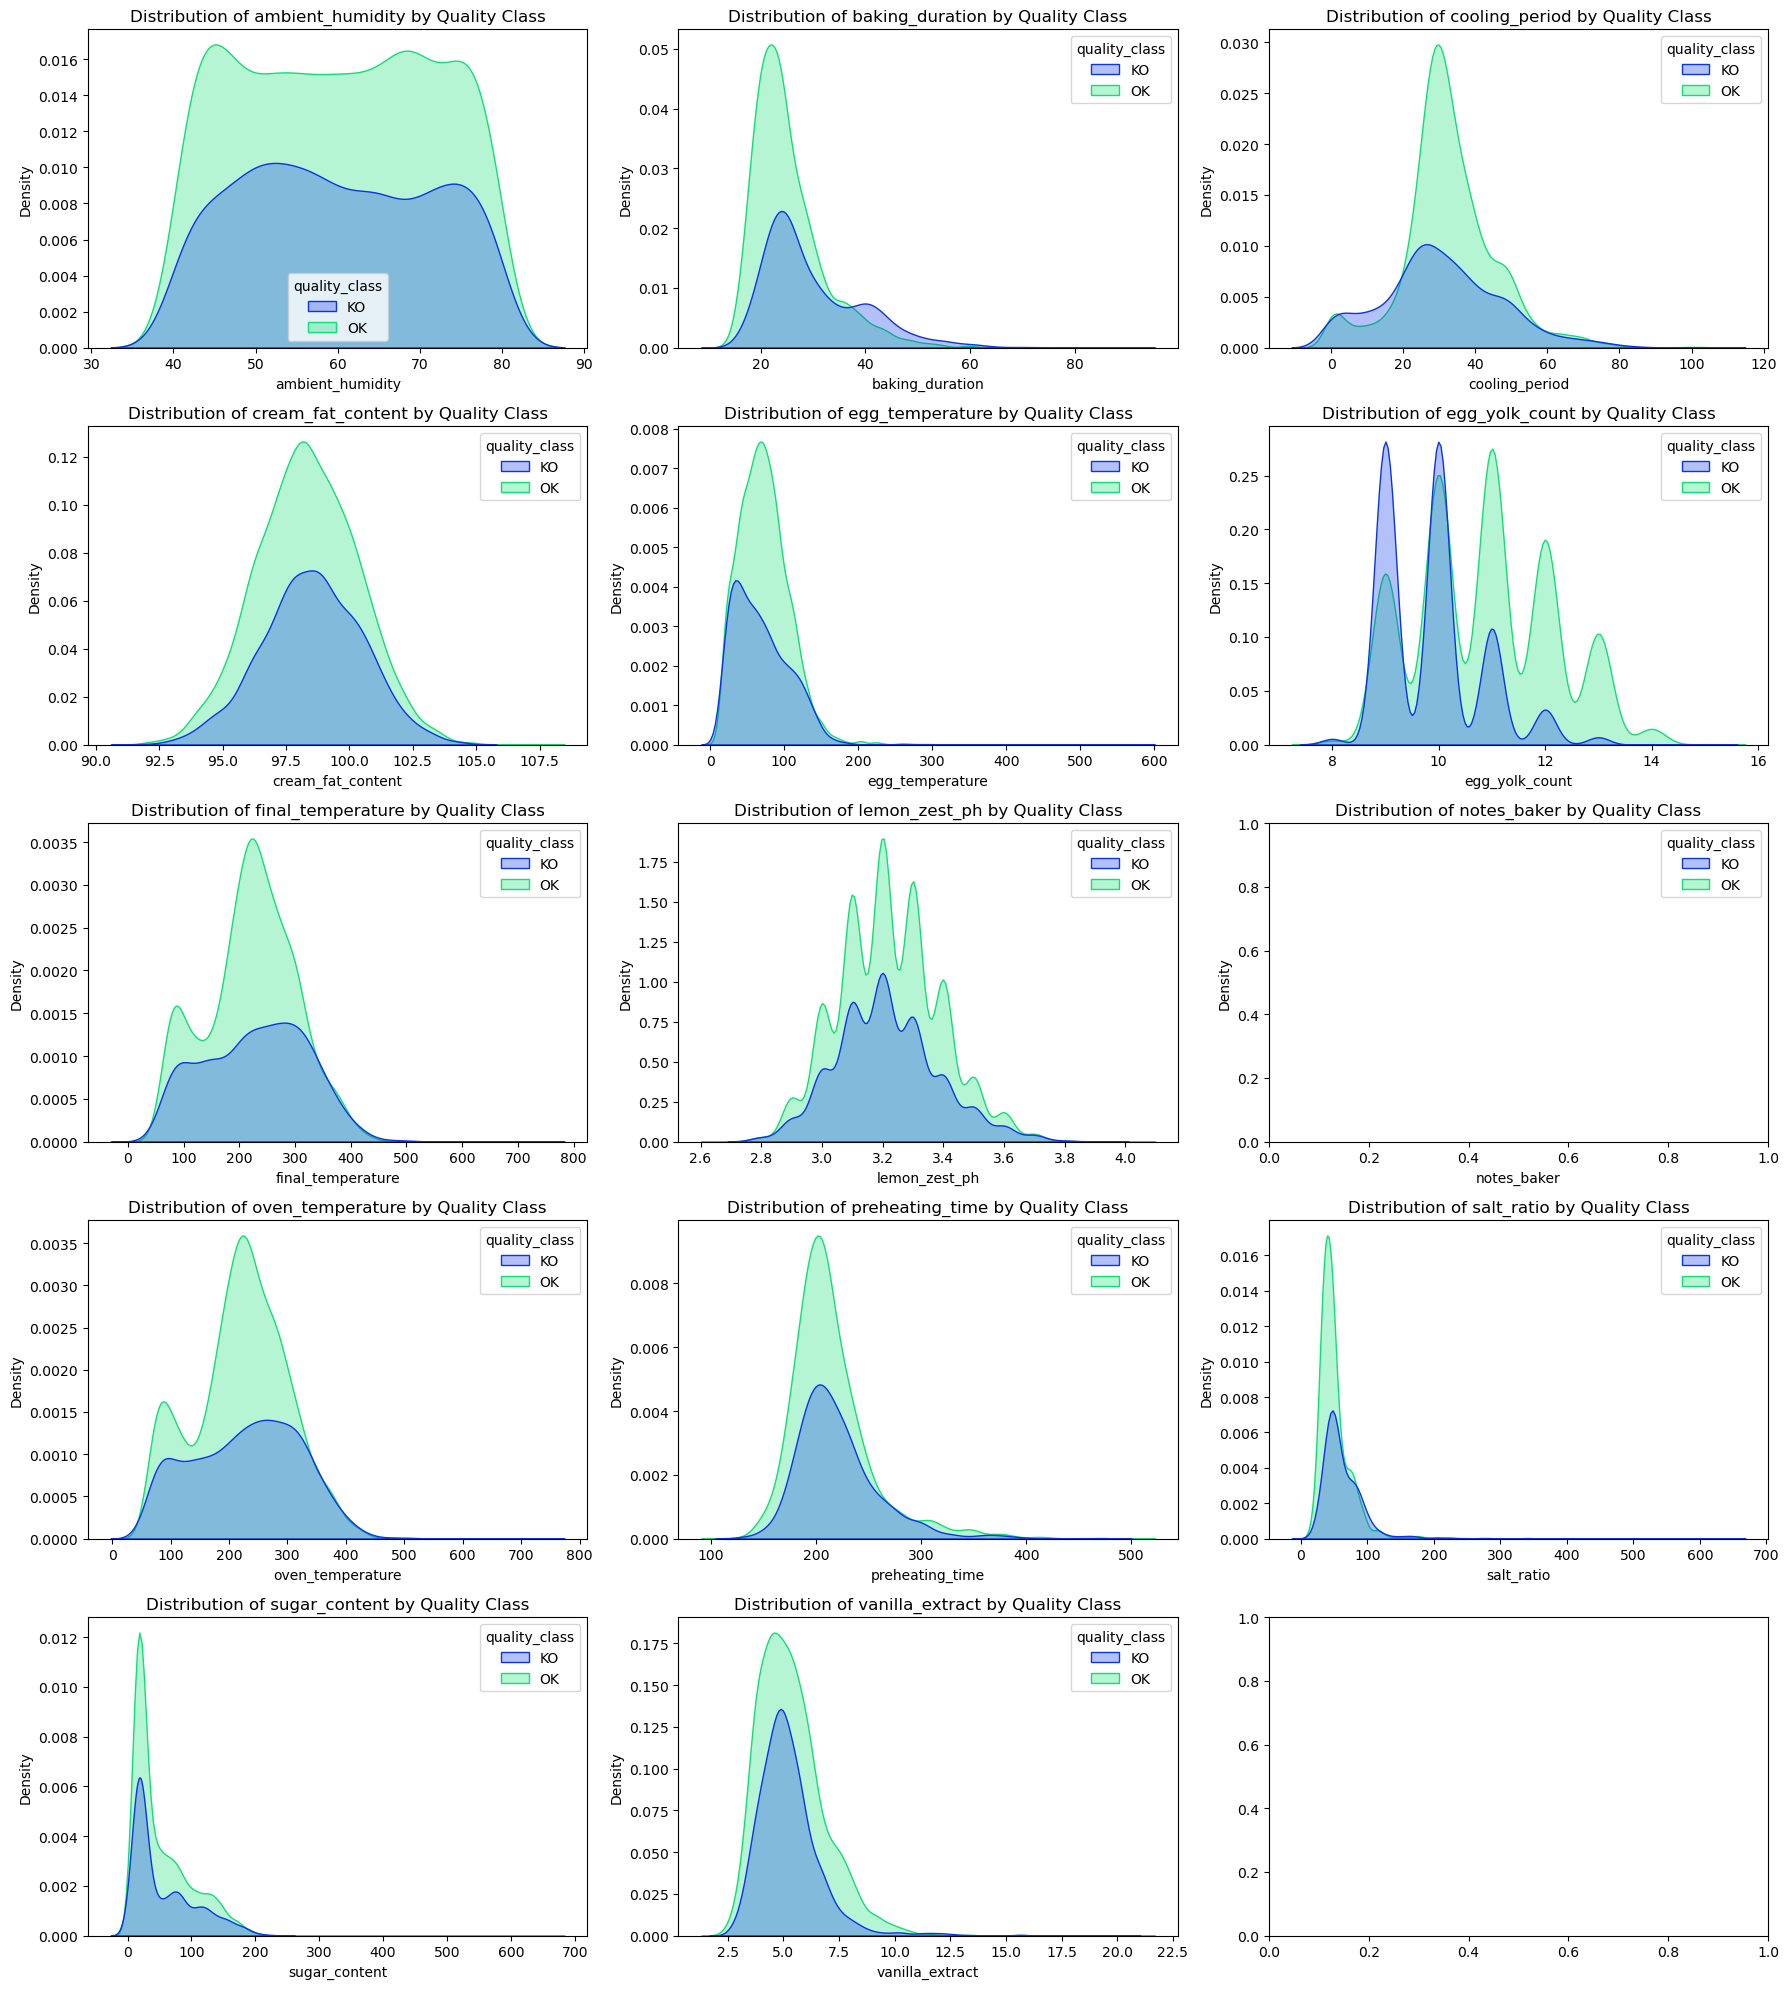

In [165]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 4 * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(x=col, 
                hue = 'quality_class', 
                data=learn_data, 
                fill = True, 
                alpha = 0.3,
                ax=axes[i], 
                palette=palette)
    axes[i].set_title(f'Distribution of {col} by Quality Class', fontsize=12)
plt.tight_layout()
plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;"><h4>The "Squashed" Features</h4>
<p>Features: <code>egg_temperature</code>, <code>final_temperature</code>, <code>oven_temperature</code>, <code>salt_ratio</code>, <code>sugar_content</code>.</p>
<p>These plots likely look like a sharp spike on the left with a long, flat tail extending to the right. The extreme outliers (e.g. 500ºC) are compressing the x-axis. It is impossible to see if there is a real difference between OK and KO in the "normal" range because the plot is zoomed out too far.</p>
<h4>The "High Overlap" Features</h4>
<p>Features: <code>ambient_humidity</code>, <code>lemon_zest_ph</code>, <code>vanilla_extract</code>.</p>
<p>The Green and Blue curves likely overlap significantly. The humidity of the room or the pH of the lemon zest doesn't seem to be the deciding factor in whether a pastel is OK or KO. These features might end up being dropped during Feature Selection.</p>
<h4>The "Shifted" Features</h4>
<p>Features: <code>baking_duration</code>, <code>cooling_period</code>, <code>preheating_time</code></p> <p>One might see that the 'OK' peak is slightly shifted compared to the 'KO' peak (e.g., 'OK' pastries might have a longer baking duration on average).These are your most promising numerical features for the initial model.</p></div>

<h3 style = "color : #0EE071;">5.3. Multivariate Analysis</h3>

<p>In this section we will try to analyse how different numerical variables correlate with each other, looking out for: Redundancy (2 features that have a very strong correlation are providing the same information) and Causality ('does a bigger <code>preheating_time</code> lead to a higher <code>oven_temperature</code>?', for example)</p>

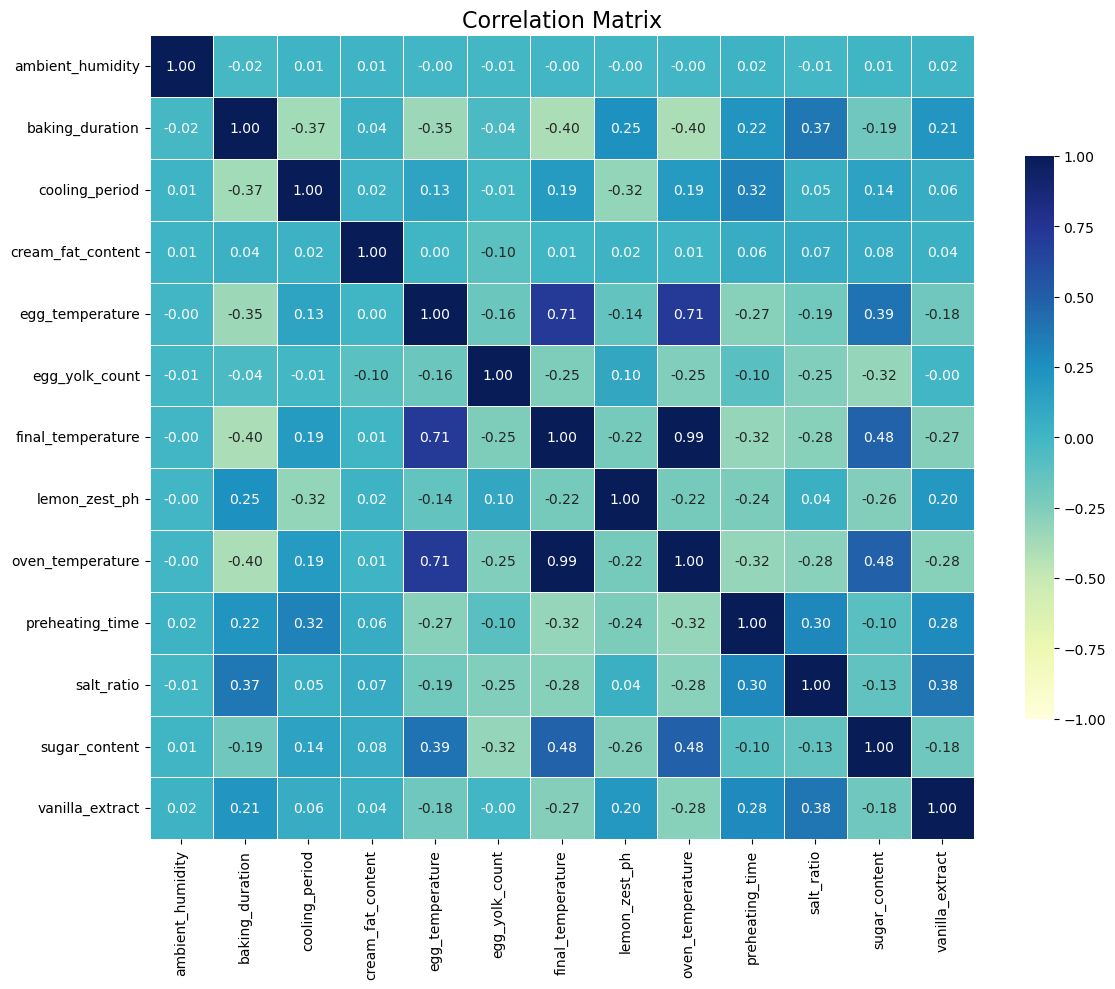

In [166]:
# Select numerical features only (excluding 'notes_baker')
numerical_data = learn_data.select_dtypes(include=np.number).drop(['notes_baker'], axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    numerical_data.corr(), 
    annot=True,       # Show the correlations
    fmt=".2f",        # 2 decimal places
    cmap='YlGnBu',    
    vmin=-1, vmax=1,  # Set scale limits
    center=0,         # Center the colormap at 0
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)

plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

<div style="border: 3px solid #0EE071; padding: 10px; border-radius: 6px;"><p>From here we cannot see strong negative correlation. Although we see one very high positive correlation between <code>final_temperature</code> and <code>oven_temperature</code>, of 0.99.</p>
<p>There are also many features which have between 0.3 and -0.3 of correlation, which indicates good independence between variables.</p></div>

<hr style = "border: 3px solid #0EE071;">
<h2 style = "color : #0EE071;">6. Major issues for Preprocessing Notebook </h2>
<p style = "font-size : 20px;">What next?</p>

<ul>
    <li><b>Duplicate Management:</b> The dataset contains <b>2 duplicate rows</b> that must be removed to prevent bias.</li>
    <li><b>Useless Features:</b> The <code>notes_baker</code> column is <b>100% empty</b> and provides no value: it should be dropped.</li>
    <li><b>Inconsistent Categorical Data:</b>
        <ul>
            <li><code>pastry_type</code> contains multiple string variations (e.g., "Pastel Nata" vs. "Pastel de nata") and is missing <b>34.4%</b> of its values.</li>
            <li><code>origin</code> contains inconsistent formatting (e.g., "Lisboa" vs. "Lisbon") that requires standardization.</li>
        </ul>
    </li>
    <li><b>Physically Impossible Outliers:</b>
        <ul>
            <li><b>Temperatures:</b> <code>egg_temperature</code>, <code>final_temperature</code>, and <code>oven_temperature</code> contain values exceeding <b>500°C</b>, which are physical impossibilities for baking.</li>
            <li><b>Ingredients:</b> <code>salt_ratio</code> and <code>sugar_content</code> contain extreme outliers (> 600g/kg) that distort the data distribution.</li>
        </ul>
    </li>
    <li><b>Missing Values Imputation:</b> Remaining missing values in numerical features need to be filled, or dropped, using appropriate strategies.</li>
</ul>

<hr style = "border: 3px solid #0EE071;">

In [167]:
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Pandas version: 2.3.2
NumPy version: 2.3.4
Matplotlib version: 3.10.6
Seaborn version: 0.13.2
